In [1]:
import tensorflow as tf
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
(xtrain, ytrain),(xtest,ytest) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


8


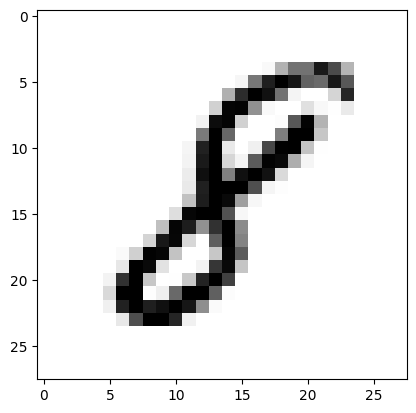

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
image_index = 7777
print(ytrain[image_index])
plt.imshow(xtrain[image_index],cmap= 'Greys')

In [3]:
xtrain.shape

(60000, 28, 28)

In [4]:
xtrain = xtrain.reshape(xtrain.shape[0], 28, 28, 1)
xtest = xtest.reshape(xtest.shape[0], 28,28,1)
input_shape = (28,28,1)

xtrain = xtrain.astype('float32')
xtest = xtest.astype('float32')

xtrain /= 255
xtest /= 255

print('x_train Shape:', xtrain.shape)
print('Number of images in x_train', xtrain.shape[0])
print('Number of images in x_test', xtest.shape[0])

x_train Shape: (60000, 28, 28, 1)
Number of images in x_train 60000
Number of images in x_test 10000


In [5]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D, Dropout, Flatten, MaxPooling2D

model = Sequential()
model.add(Conv2D(28, kernel_size=(3,3), input_shape = input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10, activation= tf.nn.softmax))

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x = xtrain, y = ytrain, epochs = 10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8909 - loss: 0.3646
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9720 - loss: 0.0872
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9833 - loss: 0.0561
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9846 - loss: 0.0448
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9892 - loss: 0.0334
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9907 - loss: 0.0283
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9919 - loss: 0.0238
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9918 - loss: 0.0248
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9938 - loss: 0.0181
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9941 - loss: 0.0177


In [7]:
model.evaluate(xtest, ytest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - loss: 0.0654


[0.055555395781993866, 0.9868000149726868]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
9


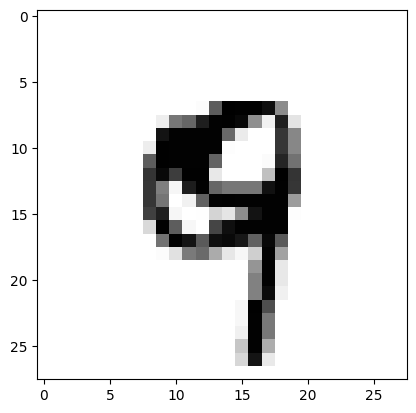

In [8]:
image_index = 4444
plt.imshow(xtest[image_index].reshape(28,28), cmap = 'Greys')
pred = model.predict(xtest[image_index].reshape(1,28,28,1))
print(pred.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1


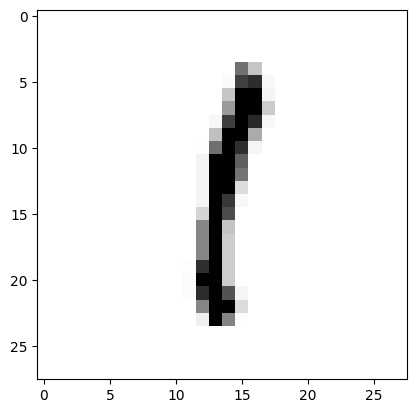

In [9]:
image_index = 3625
plt.imshow(xtest[image_index].reshape(28,28), cmap = 'Greys')
pred = model.predict(xtest[image_index].reshape(1,28,28,1))
print(pred.argmax())